In [59]:
## Simple chatbot using LangGraph

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# Reducers
from typing import Annotated
from langgraph.graph.message import add_messages


In [60]:
class State(TypedDict):
    messages: Annotated[list,add_messages]

In [61]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("AZURE_OPENAI_API_KEY")
os.environ["OPENAI_ENDPOINT"] = os.getenv("AZURE_OPENAI_ENDPOINT")
os.environ["OPENAI_API_VERSION"] = "2024-12-01-preview"
os.environ["OPENAI_DEPLOYMENT_NAME"] = "gpt-4o-mini"
os.environ["OPENAI_MODEL"] = "gpt-4o-mini"

open_api_key = os.getenv("AZURE_OPENAI_API_KEY")
if os.getenv("AZURE_OPENAI_API_KEY"):
    print(f"Azure Open API Key loaded: {open_api_key[:10]}...{open_api_key[-4:]}")
    print(f"Model: {os.getenv('OPENAI_MODEL')}")
    os.environ["OPENAI_API_KEY"] = open_api_key
else:
    print("Azure API Key not found in environment variables")
    print("Available environment variables with 'Azure':", [k for k in os.environ.keys() if 'Azure' in k.upper()])

groq_api_key = os.getenv("GROQ_API_KEY")
if os.getenv("GROQ_API_KEY"):
    print(f"GROQ API Key loaded: {groq_api_key[:10]}...{groq_api_key[-4:]}")
    os.environ["GROQ_API_KEY"] = groq_api_key
else:
    print("GROQ API Key not found in environment variables")
    print("Available environment variables with 'GROQ':", [k for k in os.environ.keys() if 'GROQ' in k.upper()])


Azure Open API Key loaded: 1Sttw3VbMy...EzVq
Model: gpt-4o-mini
GROQ API Key loaded: gsk_kJ3nEw...OOCG


In [62]:
from langchain_openai import AzureChatOpenAI
from langchain.schema import HumanMessage, SystemMessage

# Create Azure ChatOpenAI instance
llm_openai = AzureChatOpenAI(
    azure_deployment=os.getenv("OPENAI_DEPLOYMENT_NAME"),  # your deployment name
    api_version=os.getenv("OPENAI_API_VERSION"),           # API version
    azure_endpoint=os.getenv("OPENAI_ENDPOINT"),           # your endpoint URL
    api_key=os.getenv("OPENAI_API_KEY"),                   # your API key
    temperature=0.7,                                        # creativity level
    max_tokens=1000                                         # response length limit
)

print(f"Created Azure ChatOpenAI: {llm_openai}")

Created Azure ChatOpenAI: client=<openai.resources.chat.completions.completions.Completions object at 0x7ce515f503b0> async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7ce515f61d90> root_client=<openai.lib.azure.AzureOpenAI object at 0x7ce53d6e2120> root_async_client=<openai.lib.azure.AsyncAzureOpenAI object at 0x7ce515f61df0> temperature=0.7 model_kwargs={} openai_api_key=SecretStr('**********') max_tokens=1000 disabled_params={'parallel_tool_calls': None} azure_endpoint='https://zama-roadmap-to-aiml.openai.azure.com/' deployment_name='gpt-4o-mini' openai_api_version='2024-12-01-preview' openai_api_type='azure'


In [63]:
from langchain_groq import ChatGroq

# Initialize the ChatGroq model
llm_groq = ChatGroq(
    model="gemma2-9b-it",
    api_key=os.environ.get("GROQ_API_KEY")
)
print(f"Created Groq: {llm_groq}")

Created Groq: client=<groq.resources.chat.completions.Completions object at 0x7ce515f52bd0> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7ce515f52ae0> model_name='gemma2-9b-it' model_kwargs={} groq_api_key=SecretStr('**********')


In [64]:
# Create node

def superbot(state: State):
    messages = state['messages']
    response = llm_groq.invoke(messages)
    return {"messages": [response]}

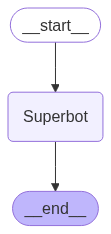

In [65]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Use the State class that was defined with messages field (from cell 2)
# Make sure we're using the correct State class
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph = StateGraph(State)

graph.add_node("Superbot", superbot)

graph.add_edge(START, "Superbot")
graph.add_edge("Superbot", END)

graph_builder = graph.compile()

# View
display(Image(graph_builder.get_graph().draw_mermaid_png()))



In [66]:
# Invoke the graph
from langchain.schema import HumanMessage

graph_builder.invoke({'messages': [HumanMessage(content="My name is Zama, I like cricket")]})

{'messages': [HumanMessage(content='My name is Zama, I like cricket', additional_kwargs={}, response_metadata={}, id='2e7823f3-281f-4d8b-bfa6-98f25ee43c58'),
  AIMessage(content="That's great, Zama! Cricket is a wonderful sport. 🏏\n\nWhat do you like most about cricket?  Do you have a favorite team or player?  😊 \n\n", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 18, 'total_tokens': 60, 'completion_time': 0.076363636, 'prompt_time': 0.001979668, 'queue_time': 0.24790604100000002, 'total_time': 0.078343304}, 'model_name': 'gemma2-9b-it', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'stop', 'logprobs': None}, id='run--fc9af95e-206e-4564-93f3-e6634bf4c354-0', usage_metadata={'input_tokens': 18, 'output_tokens': 42, 'total_tokens': 60})]}

In [72]:
for event in graph_builder.stream({"messages": [HumanMessage(content="What is my name?")]}, stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='650ff284-fbeb-4737-9e5c-08279bd972b2')]}
{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='650ff284-fbeb-4737-9e5c-08279bd972b2'), AIMessage(content="As an AI, I have no memory of past conversations and do not know your name. If you'd like to tell me, I'm happy to learn it!\n", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 14, 'total_tokens': 52, 'completion_time': 0.069090909, 'prompt_time': 0.001840158, 'queue_time': 0.241002302, 'total_time': 0.070931067}, 'model_name': 'gemma2-9b-it', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'stop', 'logprobs': None}, id='run--7591f7d6-519c-4e5c-9977-7eda0d2db883-0', usage_metadata={'input_tokens': 14, 'output_tokens': 38, 'total_tokens': 52})]}
{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, respons